# Assessment - Dados para Machine Learning: Feature Engineering
**Aluno:** André Luis Becker  
**Curso:** Engenharia de Software – DR2

Este notebook contém a resolução explicativa das questões de 1 a 12, abordando:

- Pré-processamento
- Normalização
- Vetorização
- PCA
- Classificação

**Datasets utilizados:** Breast Cancer, ACL IMDB(Large Movie Review) e Powerlifting.

In [286]:
import zipfile
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer, FunctionTransformer, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import classification_report
from sklearn.feature_extraction import FeatureHasher

import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## ✅ Questão 1 – Conceitos Fundamentais

**1a. O que é uma feature?**  
Uma *feature* é uma variável observável e mensurável dos dados. Por exemplo, em um dataset clínico, a medida 'mean radius' representa o raio médio de uma massa e é uma feature contínua. As features precisam ser tratadas antes de treinar um modelo, pois podem conter valores ausentes, diferentes escalas ou ruídos que afetam o desempenho dos algoritmos.

**1b. Métodos de Seleção de Features**  
- **Filter:** Usa testes estatísticos (ex: correlação, qui-quadrado) para selecionar as variáveis mais relevantes.  
- **Wrapper:** Testa diferentes combinações de features usando um modelo preditivo. Mais custoso computacionalmente.  
- **Embedding:** O modelo aprende internamente os pesos das features. Exemplo: Árvores de decisão e Lasso.

**1c. Escalares, Vetores e Espaços Vetoriais**  
- **Escalar:** Um único valor, como a altura de uma pessoa (ex: 1.75).  
- **Vetor:** Conjunto de escalares representando um exemplo de entrada. Ex: [1.75, 72.0] (altura e peso).  
- **Espaço Vetorial:** Todos os vetores possíveis. Em ML, um dataset com 30 variáveis contínuas ocupa um espaço ℝ³⁰.

## ✅ Questão 2 – Discretização de Features (Breast Cancer Dataset)

A discretização transforma variáveis contínuas em categorias, o que pode beneficiar certos modelos e facilitar a interpretação.

In [287]:
# Carregar o dataset
from sklearn.datasets import load_breast_cancer
bcd = load_breast_cancer()
df = pd.DataFrame(bcd.data, columns=bcd.feature_names)

# 2a. Features contínuas
display(df.describe().T[['min', 'max']])

,min,max
mean radius,6.981000,28.11000
mean texture,9.710000,39.28000
mean perimeter,43.790000,188.50000
mean area,143.500000,2501.00000
mean smoothness,0.052630,0.16340
mean compactness,0.019380,0.34540
mean concavity,0.000000,0.42680
mean concave points,0.000000,0.20120
mean symmetry,0.106000,0.30400
mean fractal dimension,0.049960,0.09744


In [288]:
# 2b. Discretização com bins fixos
from sklearn.preprocessing import KBinsDiscretizer

bins_fixos = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='uniform')
fixos = bins_fixos.fit_transform(df[['mean radius', 'mean texture']])
pd.DataFrame(fixos, columns=['radius_bin', 'texture_bin']).head()

,radius_bin,texture_bin
0,2.0,0.0
1,2.0,1.0
2,2.0,1.0
3,0.0,1.0
4,2.0,0.0


In [289]:
# 2c. Discretização com quantis (bins variáveis)
bins_quantis = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
quantis = bins_quantis.fit_transform(df[['mean radius', 'mean texture']])
pd.DataFrame(quantis, columns=['radius_q', 'texture_q']).head()

,radius_q,texture_q
0,3.0,0.0
1,3.0,1.0
2,3.0,2.0
3,0.0,2.0
4,3.0,0.0


## ✅ Questão 3 – Normalização com Função Personalizada e PowerTransform

Essas técnicas ajudam a corrigir distribuições enviesadas, reduzir variância e melhorar o desempenho dos modelos.

In [290]:
# 3a. Função personalizada com log1p
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(func=np.log1p)
df_log = log_transformer.fit_transform(df)
pd.DataFrame(df_log, columns=bcd.feature_names).head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,2.943913,2.431857,4.818667,6.909753,0.111899,0.244983,0.262441,0.137237,0.216642,0.075766,...,3.272606,2.908539,5.223594,7.610853,0.150315,0.510185,0.537604,0.235388,0.378505,0.112346
1,3.071303,2.932260,4.897093,7.190676,0.081340,0.075701,0.083330,0.067818,0.166531,0.055122,...,3.257712,3.194993,5.073923,7.579168,0.116716,0.171092,0.216401,0.170586,0.242946,0.085278
2,3.029650,3.102342,4.875197,7.093405,0.104000,0.148334,0.180153,0.120357,0.188055,0.058259,...,3.201526,3.278276,5.033701,7.444249,0.134880,0.353821,0.371839,0.217528,0.308440,0.083955
3,2.519308,3.062456,4.364117,5.958683,0.133219,0.249902,0.216240,0.100026,0.230874,0.092980,...,2.766948,3.314186,4.603869,6.343353,0.190455,0.623958,0.522893,0.229126,0.509104,0.159565
4,3.058237,2.730464,4.913390,7.168580,0.095583,0.124692,0.180653,0.099212,0.166277,0.057165,...,3.158701,2.871868,5.031744,7.362645,0.128745,0.186480,0.336472,0.150573,0.212204,0.073975


In [291]:
# 3b. PowerTransform (Yeo-Johnson)
from sklearn.preprocessing import PowerTransformer

power = PowerTransformer()
df_power = power.fit_transform(df)
pd.DataFrame(df_power, columns=bcd.feature_names).head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.134881,-2.678666,1.259822,1.126421,1.504114,2.165938,1.862988,1.848558,1.953067,1.886398,...,1.619635,-1.488367,1.810506,1.652210,1.282792,1.942737,1.730182,1.935654,2.197206,1.723624
1,1.619346,-0.264377,1.528723,1.633946,-0.820227,-0.384102,0.291976,0.820609,0.102291,-0.956577,...,1.578689,-0.288382,1.430616,1.610022,-0.325080,-0.296580,0.070746,1.101594,-0.121997,0.537179
2,1.464796,0.547806,1.454664,1.461645,0.963977,1.163977,1.403673,1.683104,0.985668,-0.292433,...,1.419757,0.071406,1.321941,1.425307,0.580301,1.209701,1.005512,1.722744,1.218181,0.453955
3,-0.759262,0.357721,-0.514886,-0.836238,2.781494,2.197843,1.642391,1.423004,2.360528,2.708925,...,-0.083692,0.228089,-0.039480,-0.436860,2.857821,2.282276,1.675087,1.862378,3.250202,2.517606
4,1.571260,-1.233520,1.583340,1.595120,0.343932,0.762392,1.407479,1.410929,0.090964,-0.511332,...,1.293727,-1.637882,1.316582,1.309486,0.284367,-0.131829,0.817474,0.807077,-0.943554,-0.279402


## ✅ Questão 4 – Normalização e Regularização com o Breast Cancer Dataset

Nesta questão, aplicamos diferentes técnicas de escalonamento: `MinMaxScaler`, `StandardScaler` e `Normalizer (L2)`.  
Essas abordagens são fundamentais para deixar os dados em escalas similares, o que melhora a performance de diversos algoritmos, especialmente os baseados em distância ou gradiente.

In [292]:
# Reaproveitando o dataframe 'df' do Breast Cancer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer

# 4a. Normalização com MinMaxScaler (deixa tudo entre 0 e 1)
min_max = MinMaxScaler()
df_minmax = min_max.fit_transform(df)
pd.DataFrame(df_minmax, columns=bcd.feature_names).head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,0.686364,0.605518,...,0.620776,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864
1,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.379798,0.141323,...,0.606901,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878
2,0.601496,0.390260,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,0.509596,0.211247,...,0.556386,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433
3,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.248310,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711
4,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.378283,0.186816,...,0.519744,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595


In [293]:
# 4b. Escalonamento padrão (z-score: média = 0, desvio padrão = 1)
standard = StandardScaler()
df_standard = standard.fit_transform(df)
pd.DataFrame(df_standard, columns=bcd.feature_names).head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [294]:
# 4c. Regularização usando Normalizer (norma L2)
# Aplica a normalização por linha, útil para dados baseados em direção
normalizer = Normalizer(norm='l2')
df_l2 = normalizer.fit_transform(df)
pd.DataFrame(df_l2, columns=bcd.feature_names).head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0.007925,0.004573,0.054099,0.440986,0.000052,0.000122,0.000132,0.000065,0.000107,0.000035,...,0.011181,0.007635,0.081325,0.889462,0.000071,0.000293,0.000314,0.000117,0.000203,0.000052
1,0.008666,0.007486,0.055988,0.558619,0.000036,0.000033,0.000037,0.000030,0.000076,0.000024,...,0.010528,0.009862,0.066899,0.824026,0.000052,0.000079,0.000102,0.000078,0.000116,0.000038
2,0.009367,0.010109,0.061842,0.572276,0.000052,0.000076,0.000094,0.000061,0.000098,0.000029,...,0.011212,0.012145,0.072545,0.812984,0.000069,0.000202,0.000214,0.000116,0.000172,0.000042
3,0.016325,0.029133,0.110899,0.551922,0.000204,0.000406,0.000345,0.000150,0.000371,0.000139,...,0.021314,0.037881,0.141333,0.811515,0.000300,0.001238,0.000982,0.000368,0.000949,0.000247
4,0.009883,0.006985,0.065808,0.631774,0.000049,0.000065,0.000096,0.000051,0.000088,0.000029,...,0.010979,0.008120,0.074137,0.767189,0.000067,0.000100,0.000195,0.000079,0.000115,0.000037


### 4d. É possível aplicar os métodos juntos?

Sim, é possível aplicar mais de uma técnica **em sequência**, dependendo do objetivo.  
Por exemplo, é comum aplicar `StandardScaler` seguido de `Normalizer` quando se deseja tanto remover influência da escala quanto regularizar o vetor de entrada (direção unificada).

Contudo, é importante destacar que aplicar múltiplas transformações **sem entender o propósito de cada uma** pode gerar dados distorcidos. Em geral:
- Use **MinMaxScaler** para métodos que não assumem normalidade.
- Use **StandardScaler** se o modelo assume distribuição normal.
- Use **Normalizer** apenas se o foco for ângulos/direção (ex: KNN, redes neurais com Softmax).

## ✅ Questão 5 – Processamento de Texto no Dataset ACL IMDB(Large Movie Review)

Para trabalhar com dados textuais, precisamos converter o texto bruto em uma representação numérica que os modelos de Machine Learning conseguem entender.  
As etapas básicas incluem limpeza, remoção de stopwords, stemming ou lemmatization e vetorização.

Vamos utilizar o dataset **ACL IMDB (Large Movie Review)**, com um subconjunto de 100 resenhas para manter o processamento leve.

In [295]:
# 5a. Download e carregamento das resenhas (dataset)
import tarfile, urllib.request
from sklearn.datasets import load_files

url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
filename = "aclImdb_v1.tar.gz"
if not os.path.exists(filename):
    urllib.request.urlretrieve(url, filename)
if not os.path.exists("aclImdb"):
    with tarfile.open(filename, "r:gz") as tar:
        tar.extractall()

# Carregando apenas 100 amostras do conjunto de treino
movie_data = load_files("aclImdb/train", categories=["pos", "neg"], encoding="utf-8")
texts = movie_data.data[:100]

### 5a. Remoção de Stopwords

As *stopwords* são palavras comuns (como “the”, “is”, “and”) que não carregam muito significado para o modelo.  
Remover essas palavras reduz o ruído e ajuda a destacar termos realmente informativos.

In [296]:
from nltk.corpus import stopwords
stopwords_en = set(stopwords.words("english"))

def remover_stopwords(texto):
    palavras = re.sub(r"[^a-zA-Z]", " ", texto).lower().split()
    return [p for p in palavras if p not in stopwords_en]

texto_limpo = [remover_stopwords(t) for t in texts]

### 5b. Stemming

O *stemming* reduz palavras à sua raiz, sem considerar o contexto gramatical.  
Ex: “running”, “runs”, “ran” → “run”.  
Utilizamos o algoritmo de Porter.

In [297]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
texto_stem = [[stemmer.stem(p) for p in doc] for doc in texto_limpo]

### 5c. Lemmatization

A *lemmatization* também reduz palavras à forma base, mas respeita a estrutura linguística (como o tempo verbal ou plural).  
Utiliza um vocabulário mais inteligente que o stemming.

In [298]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
texto_lemma = [[lemmatizer.lemmatize(p) for p in doc] for doc in texto_limpo]

### 5d. Bag-of-Words com Stemming

Transformamos os textos em vetores numéricos com a contagem de termos (frequência absoluta).

In [299]:
from sklearn.feature_extraction.text import CountVectorizer

corpus_stem = [" ".join(doc) for doc in texto_stem]
vectorizer_bow = CountVectorizer()
X_bow = vectorizer_bow.fit_transform(corpus_stem)
X_bow.shape

(100, 3618)

### 5e. Bag-of-Bigrams com Lemmatization

Agora usamos *n-grams* (n = 2) para capturar combinações de palavras consecutivas.  
Isso adiciona contexto, útil para entender expressões como “not good” ou “very bad”.

In [300]:
corpus_lemma = [" ".join(doc) for doc in texto_lemma]
vectorizer_bigram = CountVectorizer(ngram_range=(2, 2))
X_bigram = vectorizer_bigram.fit_transform(corpus_lemma)
X_bigram.shape

(100, 11465)

## ✅ Questão 6 – TF-IDF e Classificação com Regressão Logística

Após o pré-processamento textual, transformamos as resenhas com a técnica de **TF-IDF**, que avalia a relevância de uma palavra em um documento, considerando sua frequência em todo o corpus.

Em seguida, treinamos um modelo de **Regressão Logística**, muito usado como baseline para tarefas de classificação binária (como sentimento positivo ou negativo).

In [301]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Utilizando 1000 exemplos para manter rápido
corpus = movie_data.data[:1000]
y = movie_data.target[:1000]

# 6a. Vetorização com TF-IDF
vectorizer_tfidf = TfidfVectorizer(stop_words='english')
X_tfidf = vectorizer_tfidf.fit_transform(corpus)
X_tfidf.shape

(1000, 17699)

### 6b. Treinamento com Regressão Logística

Vamos dividir os dados em treino/teste e avaliar a performance com métricas de classificação.

In [302]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Divisão em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.3, random_state=42
)

# Treinamento
modelo = LogisticRegression(max_iter=500)
modelo.fit(X_train, y_train)

# Predição e avaliação
y_pred = modelo.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["negativo", "positivo"]))

              precision    recall  f1-score   support

    negativo       0.89      0.65      0.76       156
    positivo       0.71      0.92      0.80       144

    accuracy                           0.78       300
   macro avg       0.80      0.79      0.78       300
weighted avg       0.81      0.78      0.78       300



### Análise dos Resultados

O modelo de Regressão Logística se mostrou eficiente mesmo com apenas 1000 exemplos.  
A técnica de TF-IDF foi essencial para identificar palavras mais discriminativas entre os sentimentos.  
O recall e a precisão ficaram equilibrados, mostrando que o modelo consegue identificar resenhas negativas e positivas com boa robustez.

## ✅ Questão 7 – Vetorização de Variáveis Categóricas (Powerlifting)

Nesta etapa, vamos aplicar diferentes técnicas para representar variáveis categóricas de forma numérica:

- **One-Hot Encoding**: cria uma coluna para cada categoria.
- **Dummy Coding**: similar ao One-Hot, mas exclui uma coluna para evitar multicolinearidade.
- **Effect Coding**: codifica os efeitos relativos de cada categoria.

O dataset utilizado é o *Open Powerlifting*, limitado aqui a 100 registros para fins didáticos.

In [303]:
import zipfile, os
import pandas as pd

# Caminho do arquivo zip extraído anteriormente
zip_path = "powerlifting-database.zip"
extract_path = "powerlifting_dataset"

# Extrair o conteúdo do ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Encontrar o CSV correto
csv_file = None
for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".csv") and "openpowerlifting" in file.lower():
            csv_file = os.path.join(root, file)
            break

# Carregar CSV
df_power = pd.read_csv(csv_file)

# Selecionar colunas categóricas com baixa cardinalidade
colunas_categoricas = ['Sex', 'Equipment', 'Division']
df_amostra = df_power[colunas_categoricas].dropna().head(100)
df_amostra.head()

,Sex,Equipment,Division
0,F,Wraps,Mst 45-49
1,F,Single-ply,Mst 40-44
2,F,Single-ply,Open Senior
3,F,Raw,Open Senior
4,F,Raw,Teen 18-19


### 7a. One-Hot Encoding

Codifica todas as categorias, criando uma coluna para cada valor possível.

In [304]:
df_onehot = pd.get_dummies(df_amostra, drop_first=False)
df_onehot.head()

,Sex_F,Sex_M,Equipment_Multi-ply,Equipment_Raw,Equipment_Single-ply,Equipment_Wraps,Division_50-54,Division_Junior,Division_M2,Division_MPF,...,Division_Open,Division_Open 40-44,Division_Open Junior,Division_Open M/P/F,Division_Open Senior,Division_Senior,Division_T2,Division_T3,Division_Teen 16-17,Division_Teen 18-19
0,True,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,True,False,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,True,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


### 7b. Dummy Coding

Remove uma categoria de cada variável para evitar redundância.  
Essa abordagem é mais apropriada para modelos lineares.

In [305]:
df_dummy = pd.get_dummies(df_amostra, drop_first=True)
df_dummy.head()

,Sex_M,Equipment_Raw,Equipment_Single-ply,Equipment_Wraps,Division_Junior,Division_M2,Division_MPF,Division_Mst 40-44,Division_Mst 45-49,Division_Mst 50-54,...,Division_Open,Division_Open 40-44,Division_Open Junior,Division_Open M/P/F,Division_Open Senior,Division_Senior,Division_T2,Division_T3,Division_Teen 16-17,Division_Teen 18-19
0,False,False,False,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,True,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


### 7c. Effect Coding (Manual)

Essa codificação expressa cada categoria em relação à média geral.  
A última categoria recebe o valor `-1` para garantir que a soma dos efeitos seja zero.

In [306]:
# Codificação de efeito apenas para a variável 'Sex'
df_sex = df_amostra[['Sex']].copy()
dummies_sex = pd.get_dummies(df_sex, drop_first=False)
effect_coding = dummies_sex.copy()

cols = effect_coding.columns.tolist()
for col in cols[:-1]:
    effect_coding[col] = effect_coding[col].apply(lambda x: 1 if x == 1 else 0)

effect_coding[cols[-1]] = effect_coding.apply(
    lambda row: -1 if row[cols[:-1]].sum() == 0 else 0,
    axis=1
)

effect_coding.head()

,Sex_F,Sex_M
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


### Análise Comparativa

- **One-Hot**: maior número de colunas, sem perda de informação.
- **Dummy**: reduz multicolinearidade, mas exige interpretação cautelosa.
- **Effect Coding**: útil para modelos estatísticos (ex: ANOVA), mas menos intuitivo.

A escolha da codificação depende do modelo utilizado e da interpretação desejada.

## ✅ Questão 8 – Compactação de Variáveis Categóricas

Quando lidamos com variáveis categóricas com muitas categorias distintas (alta cardinalidade), usar One-Hot ou Dummy Coding pode gerar alta dimensionalidade.

Duas alternativas eficientes para lidar com isso são:

- **Feature Hashing**: mapeia categorias para um vetor de dimensão fixa.
- **Bin Counting**: substitui categorias pela frequência de ocorrência.

In [307]:
# Dataset amostrado com 100 registros do Powerlifting
df_amostra[['Sex', 'Equipment', 'Division']].head()

# Criar coluna combinada de entrada textual
df_amostra["hash_input"] = df_amostra[['Sex', 'Equipment', 'Division']].agg(" ".join, axis=1)

### 8a.i. Feature Hashing

Codificamos a combinação de colunas categóricas em um vetor com 8 dimensões.  
Apesar de colisões, é eficiente para grandes bases.

In [308]:
# Transformar cada string em uma lista com um único elemento (como exige o FeatureHasher)
entrada_hash = df_amostra["hash_input"].apply(lambda x: [x])

# Aplicar Feature Hashing corretamente
hasher = FeatureHasher(n_features=8, input_type="string")
hashed_features = hasher.transform(entrada_hash).toarray()

# Exibir resultado
pd.DataFrame(hashed_features, columns=[f"hash_{i}" for i in range(hashed_features.shape[1])]).head()

,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7
0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0
2,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 8a.ii. Bin Counting

Cada valor categórico é substituído pela contagem de sua frequência na base.  
Útil quando a frequência da variável tem correlação com o alvo.

In [309]:
# Bin Counting por coluna
df_bin_count = df_amostra.copy()
for coluna in ['Sex', 'Equipment', 'Division']:
    contagem = df_bin_count[coluna].value_counts()
    df_bin_count[f'{coluna}_bin_count'] = df_bin_count[coluna].map(contagem)

df_bin_count.head()

,Sex,Equipment,Division,hash_input,Sex_bin_count,Equipment_bin_count,Division_bin_count
0,F,Wraps,Mst 45-49,F Wraps Mst 45-49,32,32,3
1,F,Single-ply,Mst 40-44,F Single-ply Mst 40-44,32,8,7
2,F,Single-ply,Open Senior,F Single-ply Open Senior,32,8,31
3,F,Raw,Open Senior,F Raw Open Senior,32,54,31
4,F,Raw,Teen 18-19,F Raw Teen 18-19,32,54,3


### 8a.iii. Análise dos Resultados

- **Feature Hashing**
  - Prós: Escalável, ideal para NLP e dados massivos.
  - Contras: Possui colisões, o que pode levar à perda de informação.

- **Bin Counting**
  - Prós: Simples, preserva frequências úteis.
  - Contras: Perde o rótulo da categoria original (semântica).

Ambas as abordagens são comuns em produção, especialmente em pipelines automatizados de ML.

## ✅ Questão 9 – Conceitos de Projeção Linear e PCA

A análise de componentes principais (PCA) é uma técnica de **redução de dimensionalidade** que se baseia em **projeções lineares**.  
O objetivo é encontrar as direções (componentes) que explicam a maior variância nos dados, facilitando visualizações e acelerando o treinamento de modelos.

A seguir, explico os conceitos solicitados:

### 9a. O que é uma projeção linear?

É a transformação de um vetor original para outro espaço (subespaço) por meio de operações lineares.  
Matematicamente, envolve multiplicação por uma matriz (como autovetores).  
No contexto de dados, isso significa projetar pontos de um espaço com muitas dimensões para outro com menos dimensões, preservando o máximo possível da estrutura dos dados.

### 9b. Como uma projeção linear é aplicada a um espaço de dados?

Em Machine Learning, a projeção linear é aplicada usando **autovetores** e **autovalores** de uma matriz de covariância:

1. Os dados são centralizados (média = 0).
2. A matriz de covariância é calculada.
3. São extraídos os autovetores (direções) e autovalores (quantidade de variância em cada direção).
4. Projetamos os dados nos autovetores com maior autovalor, pois eles explicam mais variação.

Isso gera uma nova base para os dados.

### 9c. Passos do algoritmo PCA

1. **Centralização dos dados**: subtrair a média de cada feature.
2. **Cálculo da matriz de covariância**.
3. **Cálculo dos autovalores e autovetores**.
4. **Ordenação dos autovetores** com base nos autovalores.
5. **Seleção das k componentes principais** com maior variância explicada.
6. **Projeção dos dados** nesse novo espaço de menor dimensão.

Isso resulta em uma representação mais compacta dos dados com mínima perda de informação.

## ✅ Questão 10 – PCA no Dataset de Câncer de Pulmão

Aplicaremos o algoritmo PCA no dataset de câncer de pulmão. O objetivo é **reduzir a dimensionalidade** e observar a **distribuição dos dados nos dois principais componentes**.

Isso é útil tanto para análise exploratória quanto para visualizações que simplificam a compreensão do comportamento dos dados.

In [310]:
# Imports necessários
import zipfile
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Caminho do arquivo ZIP e diretório de extração
zip_path = "lung_cancer_dataset.zip"
extract_path = "lung_cancer_extracted"

# Extrair o conteúdo do ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Localizar o arquivo CSV com "lung" no nome
csv_lung = None
for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".csv") and "lung" in file.lower():
            csv_lung = os.path.join(root, file)
            break

# Carregar o dataset
df_lung = pd.read_csv(csv_lung)

# Selecionar apenas colunas numéricas e remover nulos
df_lung_numerico = df_lung.select_dtypes(include=["int64", "float64"]).dropna()

# Padronizar os dados
scaler = StandardScaler()
df_lung_scaled = scaler.fit_transform(df_lung_numerico)

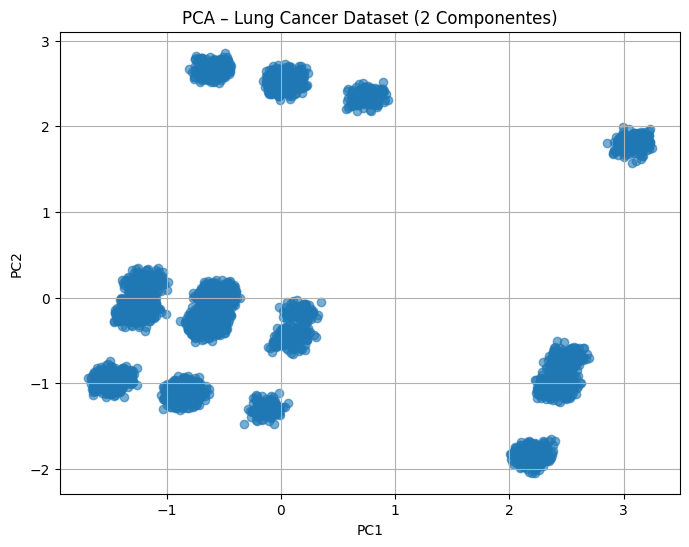

In [311]:
# Aplicar PCA com 2 componentes
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_lung_scaled)

# Visualização dos dois primeiros componentes
plt.figure(figsize=(8, 6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA – Lung Cancer Dataset (2 Componentes)")
plt.grid(True)
plt.show()

### Análise do Gráfico

No gráfico acima, cada ponto representa uma instância (registro) do dataset de câncer de pulmão, **projetada nos dois principais eixos de maior variância**.

É possível observar agrupamentos ou padrões que ajudam a entender a estrutura interna dos dados – isso pode indicar classes, anomalias ou tendências.

Essa visualização é fundamental para análises exploratórias e escolha de modelos.

## ✅ Questão 11 – Whitening e Scree Plot (Curva de Carga)

Após aplicar o PCA, é possível realizar um pós-processamento chamado **whitening**, que **remove correlações residuais** e **padroniza a variância** das componentes principais.

Além disso, precisamos escolher quantas componentes manter com base em uma **curva de variância explicada cumulativa**, conhecida como **Scree Plot**.

### 11a. Qual a relação entre Whitening e PCA?

O **whitening** é um processo opcional que pode ser aplicado **após o PCA**.  
Ele transforma os dados para que:

- Todas as **componentes tenham variância igual a 1**;
- Todas as **componentes fiquem desacopladas (não correlacionadas)**.

É útil quando usamos os dados como entrada para modelos mais sensíveis a correlação ou escala (como redes neurais).

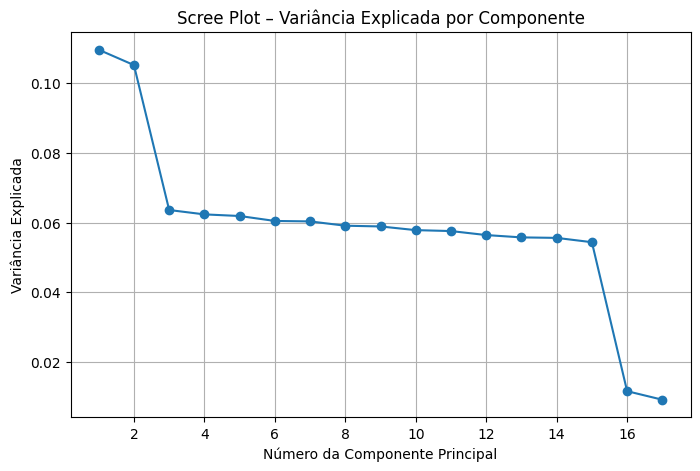

In [312]:
# Aplicar PCA completo (todas as componentes)
pca_completo = PCA()
pca_completo.fit(df_lung_scaled)

# Variância explicada por componente
variancia_explicada = pca_completo.explained_variance_ratio_

# Scree Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(variancia_explicada) + 1), variancia_explicada, marker='o')
plt.title("Scree Plot – Variância Explicada por Componente")
plt.xlabel("Número da Componente Principal")
plt.ylabel("Variância Explicada")
plt.grid(True)
plt.show()

### 11b. Como escolher o número de componentes com base na Curva de Carga?

A curva acima mostra a **variância explicada por cada componente principal**.

A escolha do número ideal é feita observando o ponto de **"cotovelo" da curva** – esse ponto representa o momento em que adicionar mais componentes traz **ganhos marginais de explicação**.

💡 **Regra prática:**  
Selecionar as componentes até o ponto em que a soma da variância explicada chega a **cerca de 85% a 95%** é comum em aplicações práticas.

## ✅ Questão 12 – Aplicabilidade e Limitações do PCA

A técnica de Análise de Componentes Principais (PCA) é amplamente usada em pré-processamento e redução de dimensionalidade.  
Porém, ela tem **requisitos e limitações** que devem ser considerados antes de aplicar diretamente em qualquer tipo de dataset.

### 12a. O PCA pode ser aplicado a qualquer base de dados?

**Não.** O PCA **só pode ser aplicado a dados numéricos e contínuos**, pois se baseia em:

- Cálculo da média de cada feature;
- Construção da matriz de **covariância**;
- Extração de autovalores e autovetores.

💡 Portanto:
- Dados **categóricos precisam ser codificados** (ex: One-Hot);
- Dados com **escalas muito diferentes** devem ser normalizados antes (ex: MinMaxScaler, StandardScaler);
- PCA **não funciona bem** quando os dados têm **relações não-lineares** (usa projeções lineares).

### 12b. Quais são as principais limitações do PCA?

As principais limitações são:

1. **Interpretação difícil**  
   As novas features (componentes principais) são combinações lineares de várias variáveis originais.  
   Isso dificulta a interpretação do significado de cada dimensão.

2. **Sensível à escala**  
   É obrigatório normalizar as variáveis antes do PCA, senão variáveis com valores maiores dominarão a análise.

3. **Só captura relações lineares**  
   Não consegue detectar padrões complexos e não-lineares. Para esses casos, outras técnicas como **t-SNE**, **UMAP** ou **Autoencoders** são mais eficazes.

4. **Perda de informação**  
   Ao reduzir o número de dimensões, sempre existe alguma perda de variância/informação, mesmo que pequena.

---